<a href="https://colab.research.google.com/github/Zhr-Srj/TripSimAcin-AMR/blob/main/Code/FeatureSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this script we're going to select features based on Information Content (IC) and Principle Component Analysis (PCA) per each drug

In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt

## Reading Dataset19 file

In [ ]:
with open(r'/content/drive/MyDrive/Dataset19.txt') as f:
    data = []
    for line in f.readlines():
        row = []
        for elem in line.split(sep=','):
            row.append(int(elem.strip()))
        data.append(row)
print(len(data))
print(len(data[0]))

7207
8886


In [ ]:
#Reading phenotypes file
with open(r'/content/drive/MyDrive/drugLabel19.txt') as fy:
    labels = []
    drugs = [] #stores drug name in each row
    row = 0 # row number of each label (is needed because data is reordered while spliting)
    reader = csv.reader(fy)
    for i in reader:
        labels.append([row, int(i[1])])
        drugs.append(i[0])
        row += 1

print(len(labels))
print(len(drugs))
print(labels[:5])

7207
7207
[[0, 1], [1, 1], [2, 0], [3, 0], [4, 1]]


## Seperating samples per drug

In [ ]:
unq_drugs = set(drugs)
len(unq_drugs)

12

In [ ]:
drugs_indexes = {}
for drug in unq_drugs:
  drugs_indexes[drug] = {0:[], 1:[]}

In [ ]:
for i in range(len(data)):
  if labels[i][1] == 0:
    drugs_indexes[drugs[i]][0].append(data[i])
  else:
    drugs_indexes[drugs[i]][1].append(data[i])

In [ ]:
drugs_indexes.keys()

dict_keys(['cefotaxime', 'levofloxacin', 'gentamicin', 'doripenem', 'ciprofloxacin', 'tetracycline', 'meropenem', 'amikacin', 'ceftriaxone', 'ceftazidime', 'moxifloxacin', 'imipenem'])

In [ ]:
drugs_indexes['imipenem'].keys()

dict_keys([0, 1])

In [ ]:
len(drugs_indexes['imipenem'][0][0])

8886

In [ ]:
for k in drugs_indexes.keys():
  print(k, ": \nRes: ", len(drugs_indexes[k][0]))
  print('Susc: ', len(drugs_indexes[k][1]))

cefotaxime : 
Res:  31
Susc:  625
levofloxacin : 
Res:  147
Susc:  507
gentamicin : 
Res:  95
Susc:  624
doripenem : 
Res:  154
Susc:  51
ciprofloxacin : 
Res:  99
Susc:  727
tetracycline : 
Res:  198
Susc:  563
meropenem : 
Res:  181
Susc:  175
amikacin : 
Res:  417
Susc:  339
ceftriaxone : 
Res:  34
Susc:  699
ceftazidime : 
Res:  109
Susc:  576
moxifloxacin : 
Res:  30
Susc:  59
imipenem : 
Res:  553
Susc:  214


## Loading SHAP-selected features

In [ ]:
with open("/content/drive/MyDrive/To_drop_features.csv") as f:
  f.readline()
  dropped_features  = [int(e) for e in f.readline().split(',')]

In [ ]:
shap_selected = [i for i in range(8005+881) if i not in dropped_features]

In [ ]:
len(shap_selected)

2996

## Loading KEGG-based feature

In [ ]:
with open('/content/drive/MyDrive/Master_new_Sep/Revise/KEGG_Columns.txt') as f:
  kegg_selected = []
  for i in f.readlines():
    kegg_selected.append(int(i.strip()))
len(kegg_selected)

96

# Calculating IC
Information content of each gene's presence/absence patterns in resistant strains compared to backgound, which is susceptible ones, per drug.

In [ ]:
IC_values = {}
for drug in unq_drugs:
  IC_values[drug] = []

In [ ]:
def IC_calculator(data):
  """
  Takes as input, data, which is a dictionary of feature vectors with keys 0
  and 1, where each such feature vector's corresponding strain is resistant and
  0 for susceptible strains' feature vectors.
  It is a per drug approach so input data corresponds to just one drug samples.
  """
  ICs = []

  Resistants = np.asarray(data[0])
  Susceptibles = np.asarray(data[1])

  for g in range(len(data[0][0])): # number of genes in a single feature vector
    # Calculating p0
    num_abs_Res = len( [e for e in Resistants[:, g] if e == 0] )
    total_Res = len(Resistants)
    p0 = (num_abs_Res + 1) / (total_Res + 2) # Considering two imaginary samples in one gene is present and in the other it's absent

    # Calculating B0
    num_abs_Sus = len( [e for e in Susceptibles[:, g] if e == 0] )
    total_sus = len(Susceptibles)
    B0 = (num_abs_Sus + 1) / (total_sus + 2)

    # Calculating p1
    num_pres_Res = len( [e for e in Resistants[:, g] if e == 1] )
    p1 = (num_pres_Res + 1) / (total_Res + 2)

    # Calculating B1
    num_pres_Sus = len( [e for e in Susceptibles[:, g] if e == 1] )
    B1 = (num_pres_Sus + 1) / (total_sus + 2)

    IC = p0*np.log2(p0/B0) + p1*np.log2(p1/B1)
    ICs.append(IC)

  return ICs

In [ ]:
for drug in unq_drugs:
  IC_values[drug] = IC_calculator(drugs_indexes[drug])

In [ ]:
for drug in unq_drugs:
  print(drug, min(IC_values[drug]), max(IC_values[drug]))

cefotaxime 0.0 2.160745864797076
levofloxacin 9.936847540750792e-07 1.8984156596745994
gentamicin 1.684506553025606e-07 2.110804812361634
doripenem 4.7046764689541096e-08 1.755042067128765
ciprofloxacin 2.7867708059963522e-08 1.8584391722033724
tetracycline 1.9376175277379076e-07 2.3409052927336327
meropenem 0.0 1.073956525717526
amikacin 1.4314019069431444e-08 1.3797538541255718
ceftriaxone 8.627224529329737e-08 2.76822310451938
ceftazidime 1.8116318726725121e-06 2.194174062428561
moxifloxacin 3.838746247891711e-05 2.1647019719771294
imipenem 1.4402860291692758e-08 1.3257826447177512


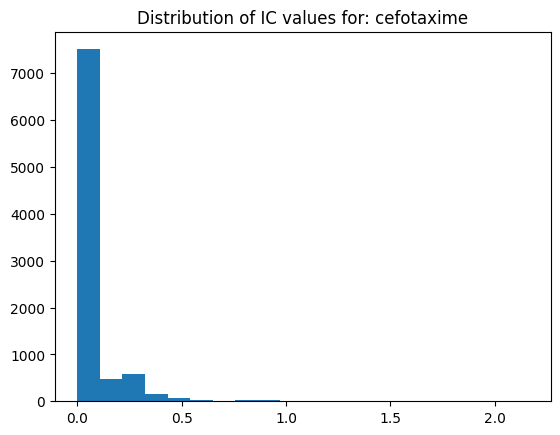

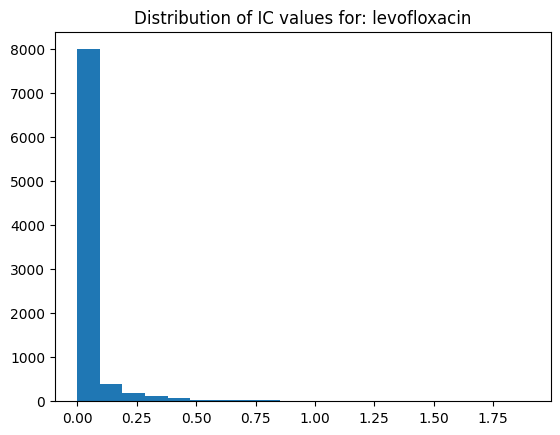

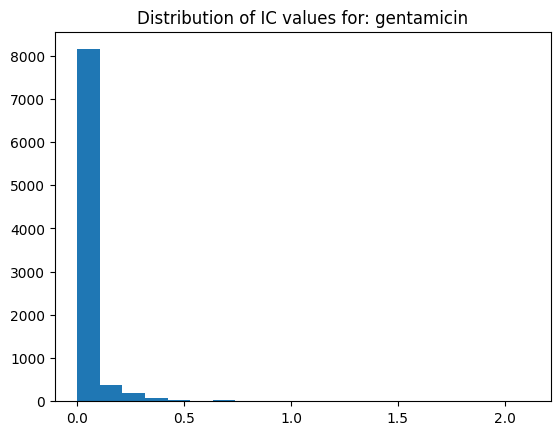

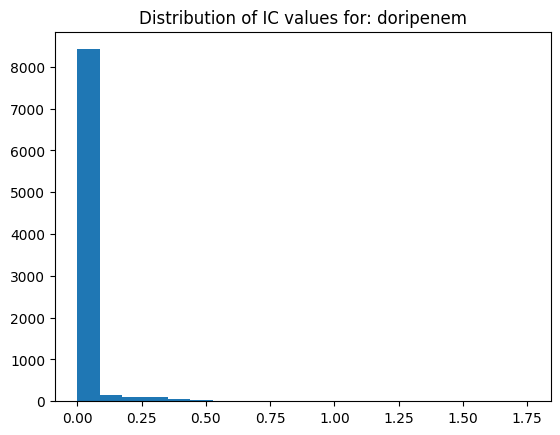

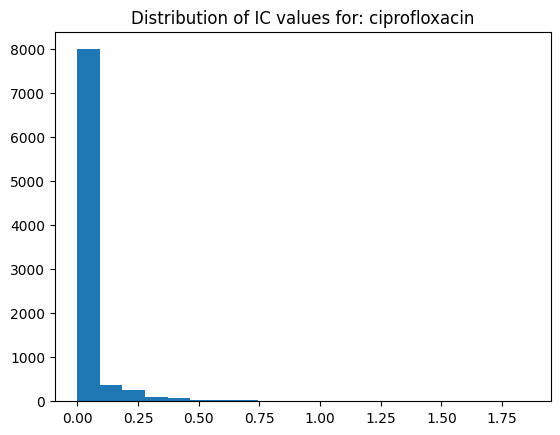

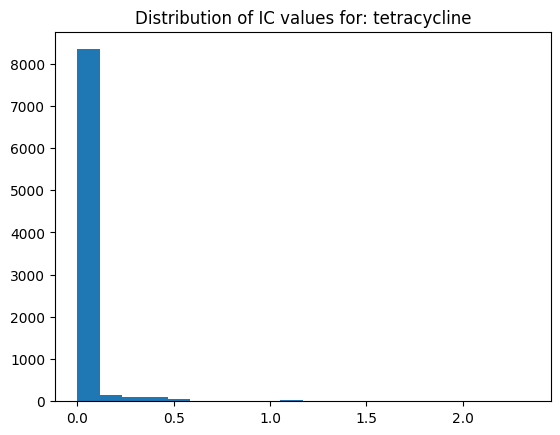

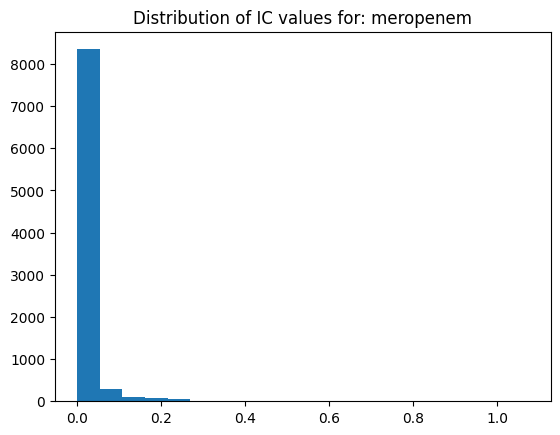

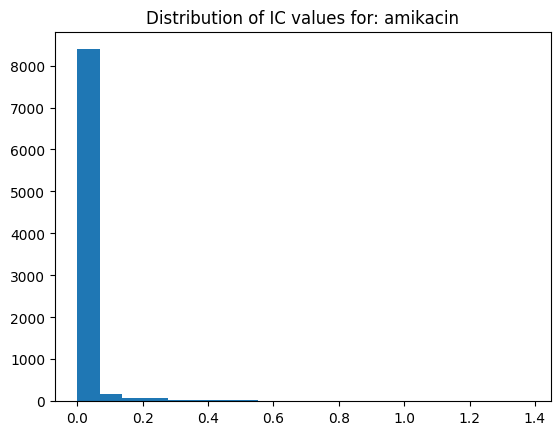

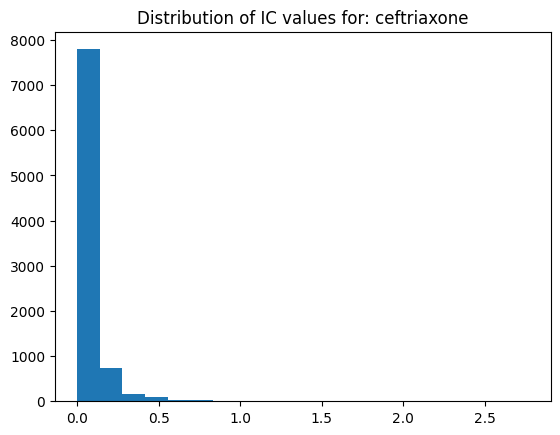

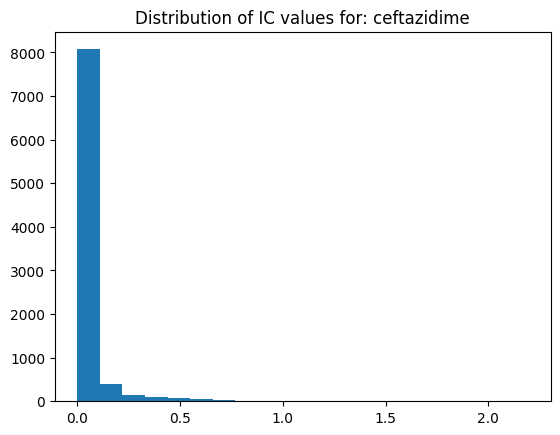

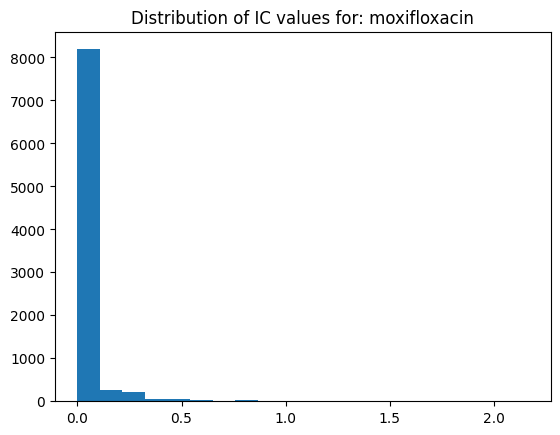

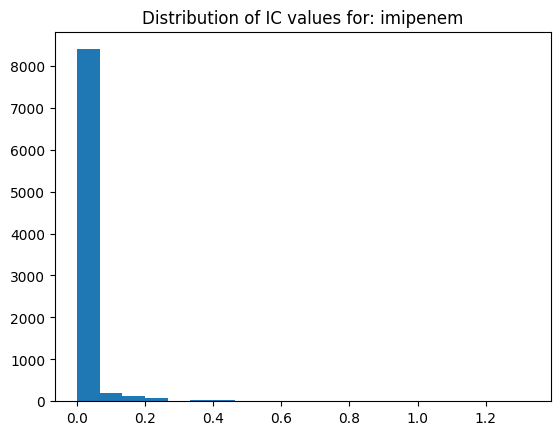

In [ ]:
for drug in unq_drugs:
  plt.hist(IC_values[drug], bins=20)
  plt.title(f"Distribution of IC values for: {drug}")
  plt.show()

In [ ]:
num_values_per_drug = []
for drug in unq_drugs:
  num_values_per_drug.append([0, 0, 0]) # number of genes with IC=0, num 0<IC<=1, num IC>1

for i, drug in enumerate(unq_drugs):
    for g in IC_values[drug]:
        if g == 0:
            num_values_per_drug[i][0] += 1
        elif 0 < g <= 1:
            num_values_per_drug[i][1] += 1
        elif g > 1:
            num_values_per_drug[i][-1] += 1

print(len(num_values_per_drug))

12


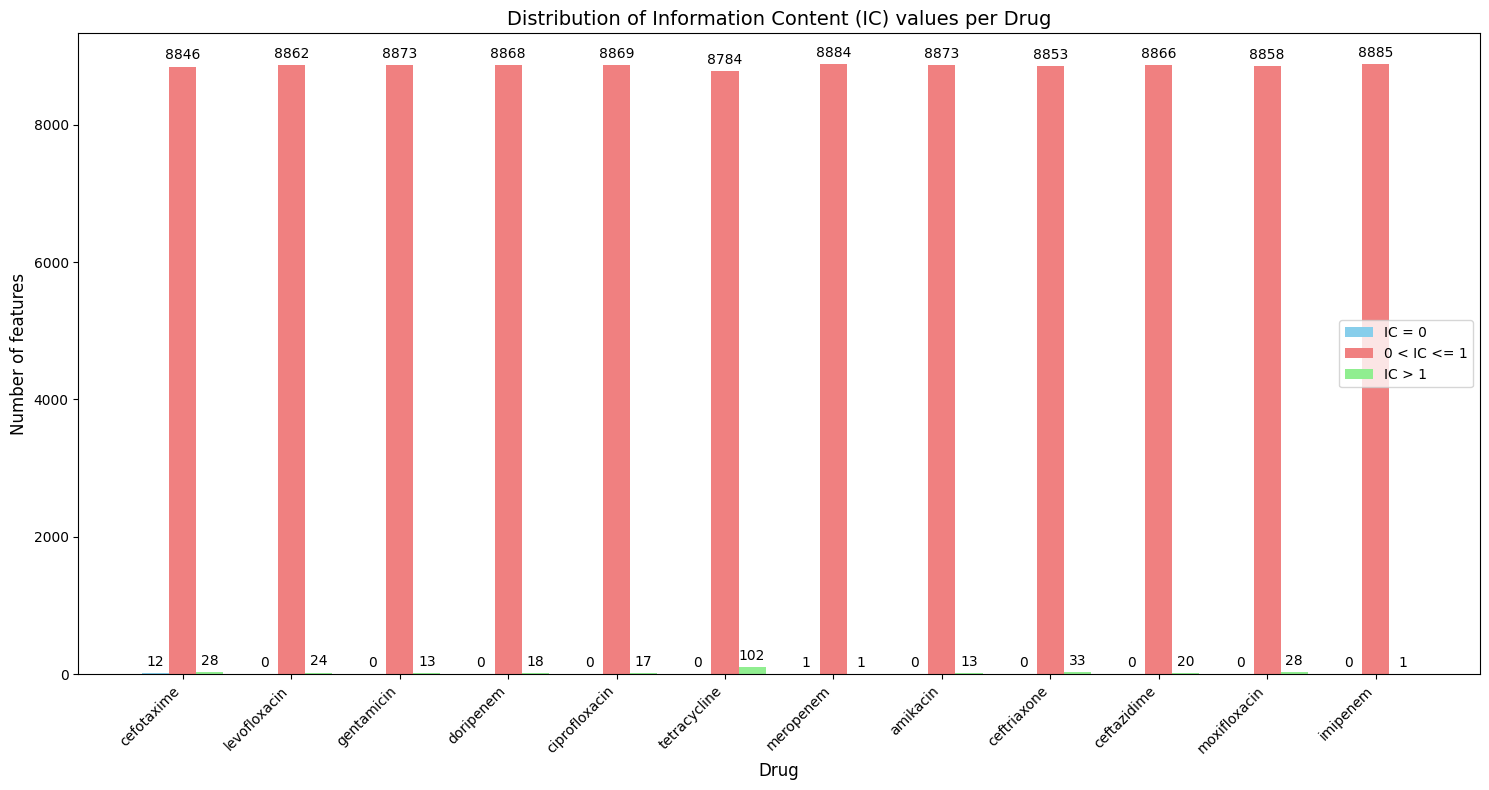

In [ ]:
drugs_list = list(unq_drugs)

fig, ax = plt.subplots(figsize=(15, 8))

bar_width = 0.25
index = np.arange(len(drugs_list))

# Create lists for each IC category for easier plotting
neg_one_ic = [val[0] for val in num_values_per_drug]
zero_ic = [val[1] for val in num_values_per_drug]
pos_ic = [val[2] for val in num_values_per_drug]

bar1 = ax.bar(index - bar_width, neg_one_ic, bar_width, label='IC = 0', color='skyblue')
bar2 = ax.bar(index, zero_ic, bar_width, label='0 < IC <= 1', color='lightcoral')
bar3 = ax.bar(index + bar_width, pos_ic, bar_width, label='IC > 1', color='lightgreen')

# Function to add numerical values on top of bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',  # Format as integer
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(bar1)
autolabel(bar2)
autolabel(bar3)

# Set labels, title and legend
ax.set_xlabel('Drug', fontsize=12)
ax.set_ylabel('Number of features', fontsize=12)
ax.set_title('Distribution of Information Content (IC) values per Drug', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(drugs_list, rotation=45, ha='right') # Rotate for better visibility
ax.legend()

plt.tight_layout()
plt.show()

## Saving index of genes with IC in 4th quartile per drug

In [ ]:
fourthq_per_drug = {}

for drug in unq_drugs:
  fourthq_per_drug[drug] = []

  q3 = np.quantile(IC_values[drug], 0.75)
  for i in range(len(IC_values[drug])):
    if IC_values[drug][i] > q3:
      fourthq_per_drug[drug].append(i)

In [ ]:
print("Number of gene indices per drug with IC value in 4th quartile:")
for drug, genes in fourthq_per_drug.items():
    print(f"  {drug}: {len(genes)} indices")

Number of gene indices per drug with IC value in 4th quartile:
  cefotaxime: 1445 indices
  levofloxacin: 2222 indices
  gentamicin: 2222 indices
  doripenem: 1188 indices
  ciprofloxacin: 2221 indices
  tetracycline: 1590 indices
  meropenem: 1962 indices
  amikacin: 1653 indices
  ceftriaxone: 1371 indices
  ceftazidime: 2219 indices
  moxifloxacin: 1517 indices
  imipenem: 1459 indices


In [ ]:
unique_union_indexes = set()
for drug in unq_drugs:
    unique_union_indexes.update(fourthq_per_drug[drug])

unique_union_indexes_list = sorted(list(unique_union_indexes))

print(f"Number of unique elements in the union of all indexes: {len(unique_union_indexes_list)}")
print(f"First 20 unique elements: {unique_union_indexes_list[:20]}")
print(f"Last 20 unique elements: {unique_union_indexes_list[-20:]}")

Number of unique elements in the union of all indexes: 3092
First 20 unique elements: [0, 3, 4, 5, 8, 9, 10, 11, 12, 13, 18, 27, 31, 36, 37, 40, 47, 50, 57, 58]
Last 20 unique elements: [7978, 7979, 7980, 7981, 7982, 7984, 7985, 7986, 7987, 7988, 7989, 7990, 7991, 7992, 7993, 7994, 7995, 7996, 7997, 7999]


In [ ]:
with open("/content/drive/MyDrive/Master_new_Sep/Revise/IC4thq_selected_features.txt", "w") as f:
    for index in unique_union_indexes_list:
        f.write(str(index)+'\n')

## Checking common ones with SHAP

In [ ]:
len(shap_selected)

2996

In [ ]:
commons = [i for i in unique_union_indexes_list if i in shap_selected]
len(commons)

2390

- 2390 items out of 2693 gene features selected by shap have high IC value
- 88% of SHAP-selected features are of high IC values.

## Checking common ones with KEGG

In [ ]:
commons_kegg_ic = [i for i in kegg_selected if i in unique_union_indexes_list]
len(commons_kegg_ic)

28

| SHAP & KEGG | SHAP & IC | KEGG & IC |
|-------------|-----------|-----------|
|    29       |    2390   |    28     |

It means that:
- Only 28 out of 96 KEGG-seleted genes are informative (~29%)
- 29 out of 96 KEGG-selected genes were picked by SHAP as well (30%)
- Many of SHAP's selected genes have high information content (88%)

# PCA analysis

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca_selected_genes_per_drug = {}

In [ ]:
for drug in unq_drugs:
    # Retrieve resistant and susceptible samples
    resistant_samples = np.asarray(drugs_indexes[drug][0])
    susceptible_samples = np.asarray(drugs_indexes[drug][1])

    # Combine samples into a single data matrix
    combined_data = np.concatenate((resistant_samples, susceptible_samples), axis=0)

    n_samples, n_features = combined_data.shape
    pca = PCA(n_components=min(n_samples, n_features))
    pca.fit(combined_data)

    importance_scores = np.sum(np.abs(pca.components_), axis=0)

    sorted_gene_indices = np.argsort(importance_scores)[::-1]

    top_1000_indices = sorted_gene_indices[:min(1000, n_features)]

    pca_selected_genes_per_drug[drug] = top_1000_indices.tolist()

In [ ]:
unique_pca_union_indexes = set()

for drug in unq_drugs:
    unique_pca_union_indexes.update(pca_selected_genes_per_drug[drug])

unique_pca_union_indexes_list = sorted(list(unique_pca_union_indexes))

print(f"Number of unique elements in the union of all PCA selected indexes: {len(unique_pca_union_indexes_list)}")
print(f"First 20 unique elements: {unique_pca_union_indexes_list[:20]}")
print(f"Last 20 unique elements: {unique_pca_union_indexes_list[-20:]}")

Number of unique elements in the union of all PCA selected indexes: 1640
First 20 unique elements: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Last 20 unique elements: [7600, 7602, 7603, 7604, 7609, 7751, 7765, 7806, 7809, 7810, 7819, 7832, 7848, 7849, 7866, 7941, 7942, 7948, 7966, 7967]


In [ ]:
with open("/content/drive/MyDrive/Master_new_Sep/Revise/PCA_selected_features.txt", "w") as f:
    for index in unique_pca_union_indexes_list:
        f.write(str(index)+'\n')

In [ ]:
print(f"Number of SHAP selected features: {len(shap_selected)}")
commons_pca_shap = [i for i in unique_pca_union_indexes_list if i in shap_selected]
print(f"Number of common features between PCA and SHAP: {len(commons_pca_shap)}")

Number of SHAP selected features: 2996
Number of common features between PCA and SHAP: 1379


In [ ]:
print(f"Number of KEGG selected features: {len(kegg_selected)}")
commons_pca_kegg = [i for i in unique_pca_union_indexes_list if i in kegg_selected]
print(f"Number of common features between PCA and KEGG: {len(commons_pca_kegg)}")

Number of KEGG selected features: 96
Number of common features between PCA and KEGG: 15


| SHAP & KEGG | SHAP & PCA | KEGG & PCA |
|-------------|------------|------------|
|    29       |    1379    |    15      |

# IC4thq-PCA overlap

In [ ]:
f = open("/content/drive/MyDrive/Master_new_Sep/Revise/IC4thq_selected_features.txt")
IC_feats = [int(i) for i in f.readlines()]
print(len(IC_feats))

3092


In [ ]:
f = open("/content/drive/MyDrive/Master_new_Sep/Revise/PCA_selected_features.txt")
PCA_feats = [int(i) for i in f.readlines()]
print(len(PCA_feats))

1640


In [ ]:
common_IC_PCA = [i for i in IC_feats if i in PCA_feats]
print(len(common_IC_PCA))

1405


# Summary of Feature Selection Overlap

| Method 1 | Method 2 | Common Features | Percentage (Common Features / Method 1) | Percentage (Common Features / Method 2) |
|----------|----------|-----------------|-----------------------------------------|-----------------------------------------|
| SHAP     | KEGG    | 29               | 1% (29/2693)                            | 30% (29/96)                             |
| SHAP     | IC       | 2390            | 88% (2390/2693)                         | 77% (2390/3092)                         |
| SHAP     | PCA      | 1379            | 46% (1379/2996)                         | 84.1% (1379/1640)                       |
| KEGG     | IC       | 28              | 29% (28/96)                             | 0.9% (28/3092)                          |
| KEGG     | PCA      | 15              | 16% (15/96)                             | 0.9% (15/1640)                          |
| IC    | PCA      | 1405              | 45% (1405/3092)                             | 85% (1405/1640)                          |
